# 05 - Neural Network Model
We build a Multi-Layer Perceptron (MLP) using TensorFlow/Keras to predict FPL points.
Results are compared against the XGBoost baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

os.makedirs('../models', exist_ok=True)

print(f'TensorFlow version: {tf.__version__}')

df = pd.read_csv('../data/processed/features.csv')
print(f'Dataset shape: {df.shape}')


TensorFlow version: 2.15.0
Dataset shape: (1519, 75)


In [2]:
# Define features and target
feature_cols = [c for c in df.columns if '_lag1' in c or '_lag2' in c] + \
               ['end_price', 'season_num', 'pos_GKP', 'pos_DEF', 'pos_MID', 'pos_FWD']
feature_cols = [c for c in feature_cols if c in df.columns]

target = 'total_points'

for col in ['pos_GKP', 'pos_DEF', 'pos_MID', 'pos_FWD']:
    if col in df.columns:
        df[col] = df[col].astype(int)

df_clean = df[feature_cols + [target, 'name', 'position', 'season_name']].dropna()

train = df_clean[df_clean['season_name'] != '2025/26']
test  = df_clean[df_clean['season_name'] == '2025/26']

X_train = train[feature_cols].values
y_train = train[target].values
X_test  = test[feature_cols].values
y_test  = test[target].values

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (611, 24), Test: (289, 24)


In [3]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '../models/nn_scaler.pkl')
print('Scaler saved.')

Scaler saved.


In [4]:
# Build MLP model
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               3200      
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 64)                

In [5]:
# Train model
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


16/16 [==============================] - 1s 12ms/step - loss: 8145.9624 - mae: 73.0914 - val_loss: 8557.6504 - val_mae: 76.1135
Epoch 2/200
16/16 [==============================] - 0s 3ms/step - loss: 7869.7490 - mae: 71.8873 - val_loss: 8373.1816 - val_mae: 75.2899
Epoch 3/200
16/16 [==============================] - 0s 3ms/step - loss: 7534.0601 - mae: 70.3927 - val_loss: 8103.6416 - val_mae: 74.0646
Epoch 4/200
16/16 [==============================] - 0s 3ms/step - loss: 7115.3662 - mae: 68.3543 - val_loss: 7728.1611 - val_mae: 72.2431
Epoch 5/200
16/16 [==============================] - 0s 3ms/step - loss: 6546.8774 - mae: 65.7112 - val_loss: 7247.2319 - val_mae: 69.7391
Epoch 6/200
16/16 [==============================] - 0s 3ms/step - loss: 5936.6519 - mae: 62.0750 - val_loss: 6638.9004 - val_mae: 66.3937
Epoch 7/200
16/16 [==============================] - 0s 3ms/step - loss: 5147.1602 - mae: 57.8087 - val_loss: 5907.7612 - val_mae: 62.0373
Epoch 8/200
16/16 [=====

In [6]:
# Training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('../data/processed/nn_training_history.png', dpi=150)
plt.show()

<Figure size 1200x400 with 2 Axes>

10/10 [==============================] - 0s 888us/step
Neural Network Test MAE:  36.53 points
Neural Network Test RMSE: 44.89 points
Neural Network Test R2:   0.305


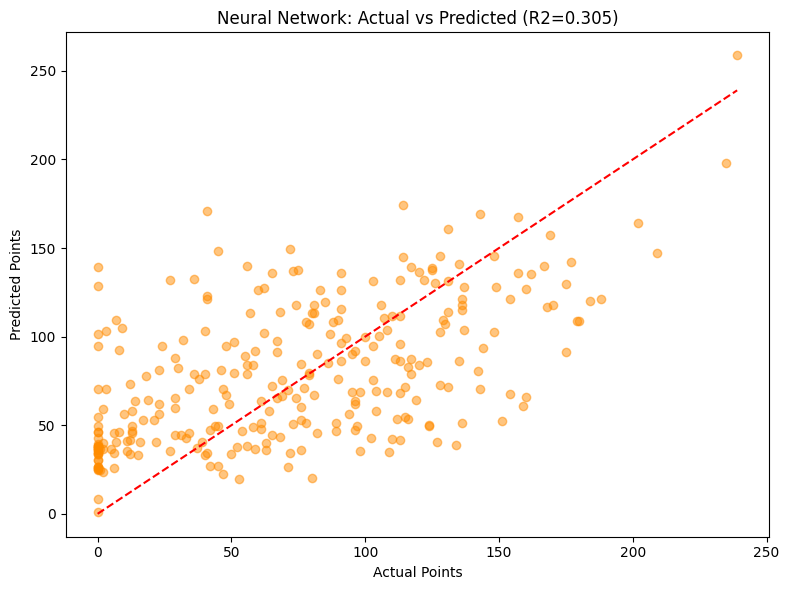

In [7]:
# Evaluate on test set
y_pred_nn = model.predict(X_test_scaled).flatten()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = mean_squared_error(y_test, y_pred_nn, squared=False)
r2_nn   = r2_score(y_test, y_pred_nn)

print(f'Neural Network Test MAE:  {mae_nn:.2f} points')
print(f'Neural Network Test RMSE: {rmse_nn:.2f} points')
print(f'Neural Network Test R2:   {r2_nn:.3f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Points')
plt.ylabel('Predicted Points')
plt.title(f'Neural Network: Actual vs Predicted (R2={r2_nn:.3f})')
plt.tight_layout()
plt.savefig('../data/processed/nn_actual_vs_predicted.png', dpi=150)
plt.show()

         Model       R2       MAE      RMSE
       XGBoost 0.300336 35.499171 45.045701
Neural Network 0.305080 36.526419 44.892741


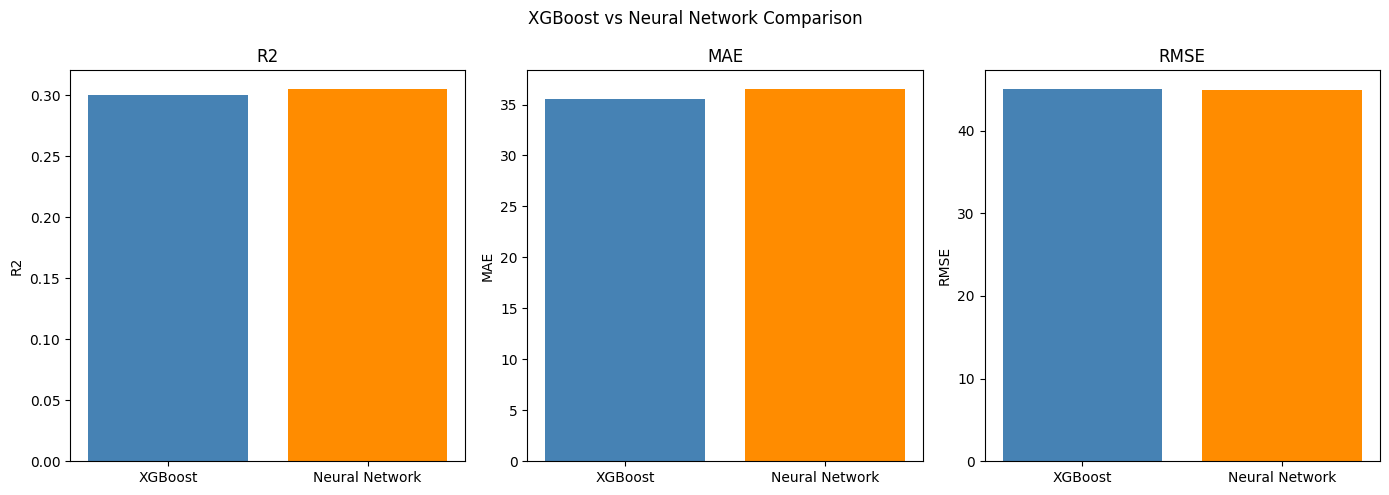

In [8]:
# Compare XGBoost vs Neural Network
xgb_preds = pd.read_csv('../data/processed/xgb_predictions.csv')
xgb_r2  = r2_score(xgb_preds['actual_points'], xgb_preds['predicted_points'])
xgb_mae = mean_absolute_error(xgb_preds['actual_points'], xgb_preds['predicted_points'])

comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network'],
    'R2': [xgb_r2, r2_nn],
    'MAE': [xgb_mae, mae_nn],
    'RMSE': [np.sqrt(mean_squared_error(xgb_preds['actual_points'], xgb_preds['predicted_points'])), rmse_nn]
})

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ['R2', 'MAE', 'RMSE']):
    ax.bar(comparison['Model'], comparison[metric], color=['steelblue', 'darkorange'])
    ax.set_title(metric)
    ax.set_ylabel(metric)

plt.suptitle('XGBoost vs Neural Network Comparison')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

In [9]:
# Save model and predictions
model.save('../models/nn_fpl.keras')

nn_results = test[['name', 'position', 'season_name']].copy()
nn_results['actual_points']    = y_test
nn_results['predicted_points'] = y_pred_nn
nn_results['error'] = nn_results['actual_points'] - nn_results['predicted_points']
nn_results = nn_results.sort_values('predicted_points', ascending=False)
nn_results.to_csv('../data/processed/nn_predictions.csv', index=False)

print('Neural network model saved.')
print('\nTop 10 predicted players (Neural Network):')
nn_results.head(10)

Neural network model saved.

Top 10 predicted players (Neural Network):


,name,position,season_name,actual_points,predicted_points,error
1094,Haaland,FWD,2025/26,239,258.792175,-19.792175
1155,B.Fernandes,MID,2025/26,235,198.070084,36.929916
503,Palmer,MID,2025/26,114,174.067871,-60.067871
1009,Isak,FWD,2025/26,41,170.832794,-129.832794
1162,Cunha,MID,2025/26,143,169.174759,-26.174759
41,Saka,MID,2025/26,157,167.777023,-10.777023
1059,Semenyo,MID,2025/26,202,164.002991,37.997009
978,Gakpo,MID,2025/26,131,160.686386,-29.686386
162,Rogers,MID,2025/26,169,157.118423,11.881577
63,Madueke,MID,2025/26,72,149.565369,-77.565369
